In [4]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm, inch
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    PageBreak, HRFlowable, KeepTogether
)
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from reportlab.platypus.flowables import Flowable
import reportlab.rl_config

# ── Color Palette ──────────────────────────────────────────────────────────────
DARK_BG      = colors.HexColor("#0D1117")
ACCENT_BLUE  = colors.HexColor("#58A6FF")
ACCENT_GREEN = colors.HexColor("#3FB950")
ACCENT_ORANGE= colors.HexColor("#F78166")
ACCENT_PURPLE= colors.HexColor("#BC8CFF")
ACCENT_YELLOW= colors.HexColor("#E3B341")
LIGHT_GREY   = colors.HexColor("#F0F4F8")
MID_GREY     = colors.HexColor("#C9D1D9")
DARK_GREY    = colors.HexColor("#21262D")
WHITE        = colors.white
TEXT_DARK    = colors.HexColor("#1C2128")
CARD_BG      = colors.HexColor("#F6F8FA")
BORDER_COLOR = colors.HexColor("#D0D7DE")

PAGE_W, PAGE_H = A4

# ── Custom Flowables ───────────────────────────────────────────────────────────
class ColorBar(Flowable):
    def __init__(self, width, height, color):
        Flowable.__init__(self)
        self.width = width; self.height = height; self.color = color
    def draw(self):
        self.canv.setFillColor(self.color)
        self.canv.roundRect(0, 0, self.width, self.height, 4, fill=1, stroke=0)

class PhaseHeader(Flowable):
    def __init__(self, number, title, subtitle, color, page_width):
        Flowable.__init__(self)
        self.number = number; self.title = title
        self.subtitle = subtitle; self.color = color
        self.width = page_width; self.height = 52

    def draw(self):
        c = self.canv
        # Background pill
        c.setFillColor(self.color)
        c.roundRect(0, 0, self.width, self.height, 10, fill=1, stroke=0)
        # Phase circle
        c.setFillColor(WHITE)
        c.circle(28, self.height/2, 16, fill=1, stroke=0)
        c.setFillColor(self.color)
        c.setFont("Helvetica-Bold", 13)
        c.drawCentredString(28, self.height/2 - 5, self.number)
        # Title
        c.setFillColor(WHITE)
        c.setFont("Helvetica-Bold", 16)
        c.drawString(56, self.height/2 + 4, self.title)
        # Subtitle
        c.setFont("Helvetica", 9)
        c.setFillColor(colors.HexColor("#FFFFFFCC"))
        c.drawString(56, self.height/2 - 10, self.subtitle)

class FlowchartBox(Flowable):
    """Mini flowchart drawn with canvas primitives."""
    def __init__(self, width, steps):
        Flowable.__init__(self)
        self.width = width
        self.steps = steps          # list of (label, color)
        box_h = 26
        gap   = 14
        self.height = len(steps) * (box_h + gap) + 10

    def draw(self):
        c   = self.canv
        bw  = self.width - 20
        bh  = 26
        gap = 14
        x   = 10
        y   = self.height - 10

        for i, (label, col) in enumerate(self.steps):
            y -= bh
            # Box
            c.setFillColor(col)
            c.setStrokeColor(colors.white)
            c.setLineWidth(1)
            c.roundRect(x, y, bw, bh, 6, fill=1, stroke=1)
            # Label
            c.setFillColor(WHITE)
            c.setFont("Helvetica-Bold", 8)
            c.drawCentredString(x + bw/2, y + 9, label)
            # Arrow
            if i < len(self.steps) - 1:
                ax = x + bw/2
                c.setStrokeColor(ACCENT_BLUE)
                c.setLineWidth(1.5)
                c.line(ax, y, ax, y - gap + 4)
                # arrowhead
                c.setFillColor(ACCENT_BLUE)
                c.setStrokeColor(ACCENT_BLUE)
                p = c.beginPath()
                p.moveTo(ax-4, y-gap+4)
                p.lineTo(ax+4, y-gap+4)
                p.lineTo(ax, y-gap-2)
                p.close()
                c.drawPath(p, fill=1, stroke=0)
            y -= gap

# ── Styles ─────────────────────────────────────────────────────────────────────
def make_styles():
    base = getSampleStyleSheet()
    S = {}

    S['cover_title'] = ParagraphStyle('cover_title',
        fontName='Helvetica-Bold', fontSize=34, textColor=WHITE,
        alignment=TA_CENTER, leading=42, spaceAfter=10)

    S['cover_sub'] = ParagraphStyle('cover_sub',
        fontName='Helvetica', fontSize=13, textColor=colors.HexColor("#A0AEC0"),
        alignment=TA_CENTER, leading=18, spaceAfter=6)

    S['cover_tag'] = ParagraphStyle('cover_tag',
        fontName='Helvetica-Bold', fontSize=10, textColor=ACCENT_GREEN,
        alignment=TA_CENTER, leading=14)

    S['section_title'] = ParagraphStyle('section_title',
        fontName='Helvetica-Bold', fontSize=15, textColor=TEXT_DARK,
        spaceBefore=14, spaceAfter=6, leading=20)

    S['topic_title'] = ParagraphStyle('topic_title',
        fontName='Helvetica-Bold', fontSize=11, textColor=ACCENT_BLUE,
        spaceBefore=8, spaceAfter=3)

    S['body'] = ParagraphStyle('body',
        fontName='Helvetica', fontSize=9.5, textColor=TEXT_DARK,
        leading=15, spaceAfter=4, alignment=TA_JUSTIFY)

    S['bullet'] = ParagraphStyle('bullet',
        fontName='Helvetica', fontSize=9, textColor=TEXT_DARK,
        leading=14, spaceAfter=2, leftIndent=14, firstLineIndent=-10)

    S['why_box'] = ParagraphStyle('why_box',
        fontName='Helvetica', fontSize=9, textColor=colors.HexColor("#2D5016"),
        leading=13, spaceAfter=2)

    S['project_title'] = ParagraphStyle('project_title',
        fontName='Helvetica-Bold', fontSize=10, textColor=ACCENT_ORANGE,
        spaceBefore=4, spaceAfter=2)

    S['tag'] = ParagraphStyle('tag',
        fontName='Helvetica-Bold', fontSize=8, textColor=WHITE,
        alignment=TA_CENTER)

    S['toc_item'] = ParagraphStyle('toc_item',
        fontName='Helvetica', fontSize=10, textColor=TEXT_DARK,
        leading=18, leftIndent=10)

    S['footer'] = ParagraphStyle('footer',
        fontName='Helvetica', fontSize=7.5, textColor=MID_GREY,
        alignment=TA_CENTER)

    S['callout'] = ParagraphStyle('callout',
        fontName='Helvetica-BoldOblique', fontSize=9.5,
        textColor=colors.HexColor("#1A3A5C"), leading=14, alignment=TA_CENTER)

    return S


def why_block(text, S):
    """Green 'Why learn this?' card."""
    tdata = [[Paragraph("<b>💡 Why learn this?</b>  " + text, S['why_box'])]]
    t = Table(tdata, colWidths=[145*mm])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), colors.HexColor("#E6F4EA")),
        ('ROUNDEDCORNERS', [6]),
        ('BOX', (0,0), (-1,-1), 1, colors.HexColor("#A8D5B5")),
        ('TOPPADDING', (0,0), (-1,-1), 6),
        ('BOTTOMPADDING', (0,0), (-1,-1), 6),
        ('LEFTPADDING', (0,0), (-1,-1), 8),
        ('RIGHTPADDING', (0,0), (-1,-1), 8),
    ]))
    return t


def resource_row(items, S):
    """Inline resource pills."""
    pills = []
    for label, col in items:
        cell = Table([[Paragraph(label, S['tag'])]], colWidths=[None])
        cell.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,-1), col),
            ('ROUNDEDCORNERS', [5]),
            ('TOPPADDING', (0,0), (-1,-1), 3),
            ('BOTTOMPADDING', (0,0), (-1,-1), 3),
            ('LEFTPADDING', (0,0), (-1,-1), 7),
            ('RIGHTPADDING', (0,0), (-1,-1), 7),
        ]))
        pills.append(cell)
    row = Table([pills], colWidths=[None]*len(pills))
    row.setStyle(TableStyle([
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ('LEFTPADDING', (0,0), (-1,-1), 2),
        ('RIGHTPADDING', (0,0), (-1,-1), 2),
    ]))
    return row


def project_card(title, desc, skills, S):
    content = [
        Paragraph(f"🚀 {title}", S['project_title']),
        Paragraph(desc, S['body']),
        Paragraph(f"<b>Skills practiced:</b> {skills}", S['bullet']),
    ]
    tdata = [[c] for c in content]
    t = Table([[Paragraph(f"🚀 {title}", S['project_title']),
                Paragraph(desc + f"  <b>Skills:</b> {skills}", S['body'])]],
              colWidths=[55*mm, 100*mm])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), colors.HexColor("#FFF8F0")),
        ('BOX', (0,0), (-1,-1), 1, colors.HexColor("#F0C070")),
        ('ROUNDEDCORNERS', [6]),
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
        ('TOPPADDING', (0,0), (-1,-1), 7),
        ('BOTTOMPADDING', (0,0), (-1,-1), 7),
        ('LEFTPADDING', (0,0), (-1,-1), 8),
        ('RIGHTPADDING', (0,0), (-1,-1), 8),
        ('LINEAFTER', (0,0), (0,-1), 1, colors.HexColor("#F0C070")),
    ]))
    return t


# ── Cover Page ─────────────────────────────────────────────────────────────────
class CoverPage(Flowable):
    def __init__(self, width, height):
        Flowable.__init__(self)
        self.width = width; self.height = height

    def draw(self):
        c = self.canv
        w, h = self.width, self.height

        # Dark gradient bg
        c.setFillColor(DARK_BG)
        c.rect(0, 0, w, h, fill=1, stroke=0)

        # Decorative circles
        for (cx, cy, r, alpha) in [(w*0.85, h*0.85, 120, 0.07),
                                    (w*0.1,  h*0.15, 90,  0.05),
                                    (w*0.5,  h*0.5,  200, 0.03)]:
            c.setFillColorRGB(0.35, 0.65, 1.0, alpha)
            c.circle(cx, cy, r, fill=1, stroke=0)

        # Top accent bar
        c.setFillColor(ACCENT_BLUE)
        c.rect(0, h-6, w, 6, fill=1, stroke=0)

        # Brain/AI icon (simple neural-net dots)
        cx2, cy2, s = w/2, h*0.68, 22
        for (dx, dy) in [(-s,s),(-s,0),(-s,-s),(0,s),(0,0),(0,-s),(s,s),(s,0),(s,-s)]:
            c.setFillColor(colors.HexColor("#1C6EF2"))
            c.circle(cx2+dx, cy2+dy, 5, fill=1, stroke=0)
        connections = [(-s,s,-s,0),(-s,0,-s,-s),(s,s,s,0),(s,0,s,-s),
                       (-s,s,0,s),(-s,0,0,0),(-s,-s,0,-s),(0,s,s,s),(0,0,s,0),(0,-s,s,-s),
                       (-s,0,0,s),(-s,0,0,-s),(0,s,s,0),(0,-s,s,0),(0,0,s,s),(0,0,s,-s)]
        c.setStrokeColor(colors.HexColor("#2A5ECC"))
        c.setLineWidth(1.2)
        for (x1,y1,x2,y2) in connections:
            c.line(cx2+x1, cy2+y1, cx2+x2, cy2+y2)
        c.setFillColor(ACCENT_BLUE)
        for (dx, dy) in [(-s,s),(-s,0),(-s,-s),(0,s),(0,0),(0,-s),(s,s),(s,0),(s,-s)]:
            c.circle(cx2+dx, cy2+dy, 4, fill=1, stroke=0)

        # Title
        c.setFillColor(WHITE)
        c.setFont("Helvetica-Bold", 36)
        c.drawCentredString(w/2, h*0.52, "ML & AI Engineer")
        c.setFont("Helvetica-Bold", 28)
        c.setFillColor(ACCENT_BLUE)
        c.drawCentredString(w/2, h*0.45, "Complete Roadmap")

        c.setFont("Helvetica", 12)
        c.setFillColor(colors.HexColor("#8B949E"))
        c.drawCentredString(w/2, h*0.39, "From Zero to Industry-Ready  •  Step-by-Step with Projects")

        # Divider
        c.setStrokeColor(ACCENT_BLUE)
        c.setLineWidth(2)
        c.line(w*0.3, h*0.36, w*0.7, h*0.36)

        # Stats row
        stats = [("7 Phases", ACCENT_BLUE), ("50+ Topics", ACCENT_GREEN),
                 ("20+ Projects", ACCENT_ORANGE), ("Full Flowchart", ACCENT_PURPLE)]
        sx = w/2 - 3*55
        for label, col in stats:
            c.setFillColor(col)
            c.roundRect(sx, h*0.28, 50, 20, 5, fill=1, stroke=0)
            c.setFillColor(WHITE)
            c.setFont("Helvetica-Bold", 8)
            c.drawCentredString(sx+25, h*0.28+7, label)
            sx += 62

        # Bottom
        c.setFont("Helvetica", 9)
        c.setFillColor(colors.HexColor("#6E7681"))
        c.drawCentredString(w/2, 25, "Crafted for Aspiring ML/AI Engineers  •  2024–2025 Edition")

# ── Main PDF Builder ───────────────────────────────────────────────────────────
def build_pdf(path):
    doc = SimpleDocTemplate(
        path, pagesize=A4,
        leftMargin=18*mm, rightMargin=18*mm,
        topMargin=16*mm, bottomMargin=16*mm,
        title="ML & AI Engineer Complete Roadmap"
    )
    S   = make_styles()
    PW  = PAGE_W - 36*mm   # usable width
    story = []

    # Cover page is drawn via onFirstPage callback — skip adding to story
    story.append(PageBreak())

    # ── HOW TO USE THIS GUIDE ──────────────────────────────────────────────────
    story.append(Paragraph("How to Use This Roadmap", S['section_title']))
    story.append(HRFlowable(width=PW, thickness=2, color=ACCENT_BLUE, spaceAfter=6))
    story.append(Paragraph(
        "This roadmap is divided into <b>7 progressive phases</b>. Each phase builds on the previous one. "
        "For every topic you will find: <b>what it is</b>, <b>why it matters in ML/AI</b>, <b>where it is used</b>, "
        "and <b>hands-on projects</b> to cement your knowledge. Follow the phases in order — do not skip. "
        "The timeline is a guide; your pace depends on your prior experience.",
        S['body']))
    story.append(Spacer(1, 6))

    # Quick overview table
    overview = [
        [Paragraph("<b>Phase</b>", S['body']),
         Paragraph("<b>Focus</b>", S['body']),
         Paragraph("<b>Duration</b>", S['body']),
         Paragraph("<b>Key Skills</b>", S['body'])],
        [Paragraph("1", S['body']), Paragraph("Foundations", S['body']),
         Paragraph("4–6 weeks", S['body']), Paragraph("Python, Math, Stats", S['body'])],
        [Paragraph("2", S['body']), Paragraph("Core ML", S['body']),
         Paragraph("6–8 weeks", S['body']), Paragraph("Scikit-learn, Algorithms", S['body'])],
        [Paragraph("3", S['body']), Paragraph("Deep Learning", S['body']),
         Paragraph("8–10 weeks", S['body']), Paragraph("PyTorch, CNNs, RNNs", S['body'])],
        [Paragraph("4", S['body']), Paragraph("Specialisations", S['body']),
         Paragraph("8–10 weeks", S['body']), Paragraph("NLP, CV, RL", S['body'])],
        [Paragraph("5", S['body']), Paragraph("MLOps & Engineering", S['body']),
         Paragraph("6–8 weeks", S['body']), Paragraph("Docker, MLflow, Cloud", S['body'])],
        [Paragraph("6", S['body']), Paragraph("Advanced AI", S['body']),
         Paragraph("8–10 weeks", S['body']), Paragraph("LLMs, Transformers, GANs", S['body'])],
        [Paragraph("7", S['body']), Paragraph("Industry & Portfolio", S['body']),
         Paragraph("Ongoing", S['body']), Paragraph("Projects, System Design", S['body'])],
    ]
    ot = Table(overview, colWidths=[12*mm, 38*mm, 28*mm, 67*mm])
    ot.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), ACCENT_BLUE),
        ('TEXTCOLOR', (0,0), (-1,0), WHITE),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [CARD_BG, WHITE]),
        ('BOX', (0,0), (-1,-1), 1, BORDER_COLOR),
        ('INNERGRID', (0,0), (-1,-1), 0.5, BORDER_COLOR),
        ('TOPPADDING', (0,0), (-1,-1), 5),
        ('BOTTOMPADDING', (0,0), (-1,-1), 5),
        ('LEFTPADDING', (0,0), (-1,-1), 6),
    ]))
    story.append(ot)
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 1 — FOUNDATIONS
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("1", "PHASE 1: Foundations",
        "Python • Mathematics • Statistics  |  4–6 Weeks",
        colors.HexColor("#1C6EF2"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph("1.1 Python Programming", S['section_title']))
    story.append(Paragraph(
        "Python is the <b>lingua franca of ML/AI</b>. Every major framework — TensorFlow, PyTorch, "
        "scikit-learn — is Python-first. You need to be fluent before touching any ML library.",
        S['body']))
    story.append(why_block(
        "Python runs 90%+ of production ML code. Numpy arrays ARE tensors. "
        "Pandas DataFrames ARE your datasets. You cannot skip this.", S))
    story.append(Spacer(1, 4))

    topics_py = [
        ("Variables, Data Types, Control Flow", "The very basics — if/else, loops, functions. Without these you cannot write a single script."),
        ("Data Structures", "Lists, dicts, sets, tuples. ML pipelines pass data through these constantly."),
        ("OOP (Classes & Objects)", "PyTorch models ARE classes. Understanding inheritance lets you build custom layers."),
        ("File I/O & Exception Handling", "Loading CSVs, JSON, images — your data lives in files. Error handling keeps pipelines robust."),
        ("NumPy", "N-dimensional arrays with vectorised math. Every ML library under the hood is NumPy ops."),
        ("Pandas", "DataFrames for loading, cleaning, exploring tabular data. Your first step with any new dataset."),
        ("Matplotlib & Seaborn", "Visualise distributions, loss curves, confusion matrices. You can not debug what you cannot see."),
    ]
    for t, d in topics_py:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(Paragraph("🔧 Resources", S['topic_title']))
    story.append(resource_row([
        ("Python.org Docs", ACCENT_BLUE), ("CS50P (free)", ACCENT_GREEN),
        ("100 Days of Code", ACCENT_ORANGE), ("Kaggle Python Course", ACCENT_PURPLE)], S))
    story.append(Spacer(1, 8))

    # Flowchart — Phase 1
    story.append(Paragraph("Phase 1 Learning Flow", S['topic_title']))
    fc_steps = [
        ("Python Basics (2 weeks)", colors.HexColor("#1C6EF2")),
        ("NumPy + Pandas (1 week)", colors.HexColor("#0D9488")),
        ("Visualisation (3 days)", colors.HexColor("#7C3AED")),
        ("Math & Stats (2 weeks)", colors.HexColor("#B45309")),
        ("Mini Projects (1 week)", colors.HexColor("#B91C1C")),
        ("→ Phase 2 Ready ✓", colors.HexColor("#15803D")),
    ]
    fc = FlowchartBox(PW * 0.45, fc_steps)

    p1_right = [
        Paragraph("1.2 Mathematics for ML", S['section_title']),
        Paragraph("<b>Linear Algebra</b>: Matrices, vectors, dot products, eigenvalues. "
                  "Neural networks are matrix multiplications at every layer. "
                  "Understanding this lets you debug shape errors and design architectures.", S['body']),
        Paragraph("<b>Calculus</b>: Derivatives, chain rule, partial derivatives. "
                  "Backpropagation IS the chain rule applied to a computation graph. "
                  "You must understand this to debug training problems.", S['body']),
        Paragraph("<b>Probability & Statistics</b>: Distributions, Bayes theorem, hypothesis testing. "
                  "Every ML model outputs probabilities. Loss functions come from probability theory.", S['body']),
        why_block("Math is the language ML is written in. You don't need a PhD level — but you MUST understand "
                  "why gradient descent moves downhill and what a matrix multiplication does.", S),
    ]
    side_tbl = Table([[fc, p1_right]], colWidths=[PW*0.42, PW*0.55])
    side_tbl.setStyle(TableStyle([
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
        ('LEFTPADDING', (0,0), (-1,-1), 0),
        ('RIGHTPADDING', (0,0), (0,-1), 10),
    ]))
    story.append(side_tbl)
    story.append(Spacer(1, 8))

    story.append(Paragraph("Phase 1 Projects", S['section_title']))
    story.append(project_card("EDA Notebook",
        "Pick any Kaggle dataset (Titanic, Iris). Load with Pandas, clean missing values, plot distributions with Seaborn, compute correlations.",
        "Pandas, NumPy, Matplotlib, Seaborn", S))
    story.append(Spacer(1, 4))
    story.append(project_card("NumPy Matrix Calculator",
        "Build a CLI that performs matrix ops (multiply, inverse, eigen) on user inputs. Print step-by-step working.",
        "NumPy, Linear Algebra", S))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 2 — CORE MACHINE LEARNING
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("2", "PHASE 2: Core Machine Learning",
        "Classical Algorithms • Scikit-learn • Model Evaluation  |  6–8 Weeks",
        colors.HexColor("#0D9488"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph(
        "Before deep learning, master the classics. They are faster to train, more interpretable, "
        "and often the right tool for tabular/structured data (which dominates industry).",
        S['body']))
    story.append(Spacer(1, 4))

    algo_data = [
        [Paragraph("<b>Algorithm</b>", S['body']),
         Paragraph("<b>What it does</b>", S['body']),
         Paragraph("<b>Used in industry for</b>", S['body'])],
        [Paragraph("Linear Regression", S['body']),
         Paragraph("Fits a line to minimise squared error", S['body']),
         Paragraph("Price prediction, forecasting", S['body'])],
        [Paragraph("Logistic Regression", S['body']),
         Paragraph("Outputs probability via sigmoid", S['body']),
         Paragraph("Spam detection, credit scoring", S['body'])],
        [Paragraph("Decision Trees", S['body']),
         Paragraph("Recursive feature splits", S['body']),
         Paragraph("Rules-based decisions, interpretable models", S['body'])],
        [Paragraph("Random Forest", S['body']),
         Paragraph("Ensemble of decorrelated trees", S['body']),
         Paragraph("Fraud detection, tabular competitions", S['body'])],
        [Paragraph("Gradient Boosting (XGBoost)", S['body']),
         Paragraph("Sequentially correct residuals", S['body']),
         Paragraph("Kaggle GOAT for tabular data, FinTech", S['body'])],
        [Paragraph("SVM", S['body']),
         Paragraph("Finds max-margin hyperplane", S['body']),
         Paragraph("Text classification, bioinformatics", S['body'])],
        [Paragraph("K-Means / DBSCAN", S['body']),
         Paragraph("Unsupervised clustering", S['body']),
         Paragraph("Customer segmentation, anomaly detection", S['body'])],
        [Paragraph("PCA / t-SNE", S['body']),
         Paragraph("Dimensionality reduction", S['body']),
         Paragraph("Visualisation, feature compression", S['body'])],
        [Paragraph("K-Nearest Neighbours", S['body']),
         Paragraph("Predict by nearest neighbours", S['body']),
         Paragraph("Recommendation, image retrieval", S['body'])],
    ]
    at = Table(algo_data, colWidths=[38*mm, 60*mm, 47*mm])
    at.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#0D9488")),
        ('TEXTCOLOR', (0,0), (-1,0), WHITE),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [CARD_BG, WHITE]),
        ('BOX', (0,0), (-1,-1), 1, BORDER_COLOR),
        ('INNERGRID', (0,0), (-1,-1), 0.5, BORDER_COLOR),
        ('TOPPADDING', (0,0), (-1,-1), 4),
        ('BOTTOMPADDING', (0,0), (-1,-1), 4),
        ('LEFTPADDING', (0,0), (-1,-1), 6),
    ]))
    story.append(at)
    story.append(Spacer(1, 8))

    story.append(Paragraph("2.1 Model Evaluation — Critical Concepts", S['section_title']))
    eval_topics = [
        ("Train/Val/Test Split & Cross-Validation",
         "If you evaluate on training data your model looks perfect but fails in production. "
         "K-Fold CV gives a reliable estimate with limited data."),
        ("Bias–Variance Tradeoff",
         "High bias = underfitting (model too simple). High variance = overfitting (memorising training data). "
         "Understanding this guides regularisation choices."),
        ("Metrics: Accuracy, Precision, Recall, F1, ROC-AUC",
         "Accuracy is misleading on imbalanced datasets. F1 balances precision/recall. "
         "ROC-AUC measures ranking quality. Know which metric your business cares about."),
        ("Regularisation (L1/L2, Dropout, Early Stopping)",
         "Prevents overfitting. L1 creates sparsity (feature selection). "
         "L2 shrinks weights. Essential for generalisation."),
        ("Hyperparameter Tuning (GridSearch, RandomSearch, Optuna)",
         "Learning rate, depth, regularisation strength — these are not learned by gradient descent. "
         "Systematic search finds the best combination."),
        ("Feature Engineering & Selection",
         "Raw data rarely feeds directly into models. Encoding categoricals, scaling numerics, "
         "creating interaction features — this is where most ML performance gains come from."),
    ]
    for t, d in eval_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))

    story.append(Spacer(1, 6))
    story.append(why_block(
        "70% of an ML engineer's time is spent on data preprocessing, feature engineering, and evaluation. "
        "Nail this phase and you will outperform engineers who jump straight to deep learning.", S))
    story.append(Spacer(1, 8))

    story.append(Paragraph("Phase 2 Projects", S['section_title']))
    p2_projs = [
        ("House Price Predictor",
         "Regression end-to-end: EDA → feature engineering → train multiple models → compare RMSE. "
         "Deploy a simple prediction function.",
         "Linear Regression, Random Forest, XGBoost, Pipelines"),
        ("Customer Churn Classifier",
         "Binary classification on telecom data. Handle class imbalance with SMOTE. "
         "Tune threshold for business ROI.",
         "Logistic Regression, SVM, Evaluation Metrics"),
        ("Mall Customer Segmentation",
         "Cluster customers by spending habits. Visualise with PCA + t-SNE. "
         "Interpret business meaning of each cluster.",
         "K-Means, DBSCAN, PCA, Seaborn"),
    ]
    for title, desc, skills in p2_projs:
        story.append(project_card(title, desc, skills, S))
        story.append(Spacer(1, 4))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 3 — DEEP LEARNING
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("3", "PHASE 3: Deep Learning",
        "Neural Networks • PyTorch • CNNs • RNNs  |  8–10 Weeks",
        colors.HexColor("#7C3AED"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph(
        "Deep learning powers the most impressive AI today — image recognition, speech, translation, "
        "protein folding, generative AI. PyTorch is the framework of choice for researchers and increasingly for production.",
        S['body']))
    story.append(Spacer(1, 4))

    dl_topics = [
        ("Perceptron & Multilayer Perceptrons (MLP)",
         "The fundamental building block. Understand forward pass (weighted sum + activation) "
         "and why depth creates representational power."),
        ("Activation Functions (ReLU, Sigmoid, Softmax, GELU)",
         "Non-linearities let networks learn non-linear patterns. ReLU prevents vanishing gradients. "
         "Softmax converts logits to probabilities for classification."),
        ("Backpropagation & Gradient Descent",
         "THE core algorithm. Chain rule propagates error signal backwards. "
         "Understand this to debug NaN losses, exploding gradients, and dead neurons."),
        ("Optimisers (SGD, Adam, AdamW, LR Schedulers)",
         "Adam adapts learning rates per parameter — the default for most tasks. "
         "LR warmup + cosine decay is standard for transformers."),
        ("Loss Functions (MSE, CrossEntropy, BCE, Huber, Contrastive)",
         "Loss defines what you optimise. Wrong loss = model optimises the wrong thing. "
         "NLL / CrossEntropy is the standard for classification."),
        ("Batch Normalisation & Layer Normalisation",
         "Normalise activations to stabilise training. BatchNorm for CNNs, LayerNorm for Transformers. "
         "Allows higher learning rates and faster convergence."),
        ("Dropout & Weight Decay",
         "Dropout randomly zeroes neurons during training — forces redundant representations. "
         "Weight decay (L2 on parameters) prevents any single weight dominating."),
        ("Convolutional Neural Networks (CNNs)",
         "Local feature detectors with weight sharing. Hierarchically learn edges → textures → objects. "
         "Powers all image AI: medical imaging, autonomous vehicles, face recognition."),
        ("Recurrent Networks (RNN, LSTM, GRU)",
         "Process sequences by maintaining hidden state. LSTM/GRU solve the vanishing gradient problem in RNNs. "
         "Still used for time series and speech."),
        ("PyTorch Core: Tensors, Autograd, nn.Module, DataLoader",
         "PyTorch's dynamic computation graph makes debugging natural. "
         "Autograd records ops for automatic differentiation. nn.Module structures your model."),
    ]
    for t, d in dl_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))

    story.append(Spacer(1, 6))
    story.append(why_block(
        "PyTorch is now used by 75%+ of ML research papers and increasingly in production. "
        "Learning to read and write PyTorch code is non-negotiable for any serious ML engineer.", S))
    story.append(Spacer(1, 8))

    story.append(Paragraph("3.1 Training Best Practices", S['section_title']))
    bp_items = [
        "Always overfit a single batch first — confirms your model and loss function are correct.",
        "Monitor train vs validation loss curves in real time (use TensorBoard or W&B).",
        "Use gradient clipping for RNNs and transformers to prevent exploding gradients.",
        "Learning rate finder: start with 1e-7, increase exponentially, plot loss — pick the steepest descent.",
        "Mixed precision training (torch.amp) halves memory and doubles throughput on modern GPUs.",
        "Reproducibility: set torch.manual_seed, numpy seed, and Python random seed.",
    ]
    for item in bp_items:
        story.append(Paragraph(f"✓  {item}", S['bullet']))

    story.append(Spacer(1, 8))
    story.append(Paragraph("Phase 3 Projects", S['section_title']))
    p3_projs = [
        ("MNIST Digit Classifier",
         "Your 'Hello World' of deep learning. MLP first, then CNN. Watch accuracy jump from ~97% to ~99.4%. "
         "Visualise learned filters.",
         "PyTorch, MLP, CNN, Training Loop"),
        ("CIFAR-10 Image Classifier",
         "10-class colour image classification. Implement data augmentation (random crop, flip). "
         "Try ResNet-18 vs custom CNN.",
         "CNNs, Transfer Learning, Augmentation"),
        ("Sentiment LSTM",
         "Binary sentiment on IMDB reviews. Build vocab, tokenise, pad sequences, train LSTM. "
         "Compare with pre-trained embeddings.",
         "LSTM, NLP Basics, Embeddings"),
        ("Time Series Forecasting",
         "Predict stock/weather with LSTM. Use rolling windows as features. "
         "Evaluate with MAE and visualise predictions.",
         "LSTM, Time Series, PyTorch"),
    ]
    for title, desc, skills in p3_projs:
        story.append(project_card(title, desc, skills, S))
        story.append(Spacer(1, 4))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 4 — SPECIALISATIONS
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("4", "PHASE 4: Specialisations",
        "NLP • Computer Vision • Reinforcement Learning  |  8–10 Weeks",
        colors.HexColor("#B45309"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph("4.1 Natural Language Processing (NLP)", S['section_title']))
    nlp_topics = [
        ("Tokenisation, Stemming, Lemmatisation",
         "Convert raw text to processable tokens. Crucial pre-processing before any text model."),
        ("Word Embeddings (Word2Vec, GloVe, FastText)",
         "Map words to dense vectors capturing semantic meaning. 'king - man + woman ≈ queen'. "
         "Foundation of all modern NLP."),
        ("Attention Mechanism",
         "Allows model to focus on relevant tokens. The key innovation enabling Transformers. "
         "Understand scaled dot-product attention before touching BERT/GPT."),
        ("Transformer Architecture",
         "Encoder-decoder with multi-head self-attention. Powers BERT, GPT, T5, LLaMA. "
         "Read 'Attention Is All You Need' paper."),
        ("Hugging Face Transformers Library",
         "Pre-trained models for classification, NER, QA, translation, generation. "
         "The standard toolbox for any NLP task."),
        ("Fine-tuning Pre-trained Models",
         "Take BERT/RoBERTa, add classification head, train on your task with small dataset. "
         "This is how 90% of NLP in production works."),
    ]
    for t, d in nlp_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(Paragraph("4.2 Computer Vision (CV)", S['section_title']))
    cv_topics = [
        ("Image Pre-processing & Augmentation (Albumentations, torchvision)",
         "Normalise, resize, random crops, colour jitter. Augmentation multiplies effective dataset size."),
        ("Transfer Learning & Fine-tuning (ResNet, EfficientNet, ViT)",
         "ImageNet pre-trained models carry powerful features. Fine-tune the last layers for your domain. "
         "Reduces training time from weeks to hours."),
        ("Object Detection (YOLO, Faster R-CNN)",
         "Localise AND classify objects. Powers autonomous driving, retail checkout, security cameras."),
        ("Semantic Segmentation (U-Net, DeepLab)",
         "Classify every pixel. Medical imaging (tumour segmentation) and satellite imagery rely on this."),
        ("Vision Transformers (ViT, DINO)",
         "Apply transformer attention to image patches. State-of-the-art on many benchmarks."),
    ]
    for t, d in cv_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(Paragraph("4.3 Reinforcement Learning (RL)", S['section_title']))
    rl_topics = [
        ("MDP, States, Actions, Rewards, Policy, Value Function",
         "The formal framework. An agent takes actions in an environment to maximise cumulative reward."),
        ("Q-Learning & Deep Q-Networks (DQN)",
         "Learn a value function with a neural net. Famously used by DeepMind to beat Atari games."),
        ("Policy Gradient Methods (REINFORCE, PPO)",
         "Directly optimise the policy. PPO is used to train ChatGPT (RLHF)."),
        ("Multi-Armed Bandit Problems",
         "Simpler RL for recommendation systems and A/B testing optimisation."),
    ]
    for t, d in rl_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(why_block(
        "Pick ONE specialisation to go deep in first. NLP is the hottest area (LLMs). "
        "CV has the most industry jobs. RL is needed for robotics and game AI.", S))
    story.append(Spacer(1, 8))

    story.append(Paragraph("Phase 4 Projects", S['section_title']))
    p4_projs = [
        ("News Category Classifier",
         "Fine-tune DistilBERT on AG News dataset. Deploy as a REST API with FastAPI. "
         "Handles 20 categories with 94%+ accuracy.",
         "HuggingFace, BERT, FastAPI, Fine-tuning"),
        ("Real-time Object Detector",
         "Train YOLOv8 on a custom dataset (e.g. hardhat detection). "
         "Run inference on webcam stream. Count detected objects per frame.",
         "YOLOv8, OpenCV, Transfer Learning"),
        ("RL Cart-Pole Agent",
         "Train DQN to balance a pole. Use OpenAI Gym. "
         "Plot reward curves and visualise learned policy.",
         "PyTorch, DQN, OpenAI Gym"),
    ]
    for title, desc, skills in p4_projs:
        story.append(project_card(title, desc, skills, S))
        story.append(Spacer(1, 4))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 5 — MLOPS & ENGINEERING
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("5", "PHASE 5: MLOps & ML Engineering",
        "Deployment • Monitoring • Pipelines • Cloud  |  6–8 Weeks",
        colors.HexColor("#0891B2"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph(
        "A model that lives only in a notebook is worthless. MLOps bridges research and production. "
        "This is what separates an ML engineer from a data scientist.",
        S['body']))
    story.append(Spacer(1, 4))

    mlops_sections = [
        ("Version Control & Experiment Tracking",
         [("Git & GitHub", "Track every code change. Branch per experiment. PRs for code review. Non-negotiable for team work."),
          ("DVC (Data Version Control)", "Version your datasets and model artefacts alongside code. Reproducibility requires this."),
          ("MLflow / Weights & Biases", "Log metrics, hyperparameters, artefacts per run. Compare experiments visually. "
                                         "W&B is industry standard; MLflow is open source.")]),
        ("Model Serving & APIs",
         [("FastAPI", "Build REST APIs for your models in Python. Async, fast, auto-generates OpenAPI docs."),
          ("TorchServe / TF Serving", "Production-grade model servers with batching, versioning, health checks."),
          ("ONNX Export", "Convert models to a hardware-agnostic format. Enables deployment on edge devices, mobile, and different runtimes.")]),
        ("Containerisation & Orchestration",
         [("Docker", "Package your model + dependencies + environment into a reproducible container. "
                     "If it runs on your laptop in Docker, it runs in production."),
          ("Docker Compose", "Run multi-service stacks locally (model server + database + frontend)."),
          ("Kubernetes (K8s) basics", "Orchestrate containers at scale. Know Pods, Services, Deployments, HPA. "
                                     "Industry standard for large-scale ML serving.")]),
        ("ML Pipelines",
         [("Apache Airflow", "Schedule and orchestrate data pipelines as DAGs. Retries, alerts, history."),
          ("Prefect / ZenML", "Modern alternatives to Airflow with better ML-specific features."),
          ("Feature Stores (Feast)", "Centralise and reuse features across models. Prevent training-serving skew.")]),
        ("Cloud Platforms",
         [("AWS SageMaker / GCP Vertex AI / Azure ML", "Managed training, deployment, monitoring. Know at least one cloud ML platform."),
          ("S3 / GCS / Azure Blob", "Store datasets, model artefacts, logs in object storage."),
          ("Lambda / Cloud Functions", "Serverless inference for low-traffic endpoints — cost-efficient.")]),
        ("Monitoring & Reliability",
         [("Data Drift Detection (Evidently AI, Alibi Detect)", "Production models degrade as data distributions shift. Detect it early."),
          ("Model Performance Monitoring", "Track prediction distributions, latency, error rates in production dashboards."),
          ("A/B Testing", "Roll out new models safely by routing a fraction of traffic. "
                          "Statistical test determines if new model is better.")]),
    ]

    for section, items in mlops_sections:
        story.append(Paragraph(f"5.x {section}", S['section_title']))
        for t, d in items:
            story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
        story.append(Spacer(1, 4))

    story.append(why_block(
        "MLOps skills command a 30–50% salary premium. Most ML researchers cannot deploy. "
        "If you can build AND ship, you are immediately more valuable to any company.", S))
    story.append(Spacer(1, 8))

    story.append(Paragraph("Phase 5 Projects", S['section_title']))
    p5_projs = [
        ("ML API Deployment",
         "Take your Phase 2/3 model → wrap with FastAPI → containerise with Docker → "
         "push to Docker Hub → deploy on AWS EC2 or Render.com. Add /predict and /health endpoints.",
         "FastAPI, Docker, AWS/GCP, REST APIs"),
        ("Full MLOps Pipeline",
         "Data ingest (S3) → feature engineering (Airflow DAG) → training (SageMaker/Colab) → "
         "experiment tracking (MLflow) → serving (FastAPI) → monitoring (Evidently). "
         "A complete end-to-end system.",
         "MLflow, DVC, Airflow, Docker, Cloud"),
    ]
    for title, desc, skills in p5_projs:
        story.append(project_card(title, desc, skills, S))
        story.append(Spacer(1, 4))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 6 — ADVANCED AI
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("6", "PHASE 6: Advanced AI",
        "LLMs • Generative AI • Multimodal • Research  |  8–10 Weeks",
        colors.HexColor("#9333EA"), PW))
    story.append(Spacer(1, 8))

    adv_sections = [
        ("Large Language Models (LLMs)",
         [("Transformer Architecture Deep Dive (GPT, BERT, T5, LLaMA)",
           "Understand multi-head attention, positional encoding, KV cache. "
           "Read original papers: 'Attention Is All You Need', GPT-1/2/3 papers."),
          ("Pre-training Objectives (CLM, MLM, Seq2Seq)",
           "GPT uses causal language modelling (predict next token). BERT uses masked LM. "
           "Objective shapes the model's capability."),
          ("RLHF (Reinforcement Learning from Human Feedback)",
           "How ChatGPT was aligned to human preferences. Train reward model on human rankings, "
           "then PPO to optimise policy. Cutting-edge alignment research."),
          ("Parameter-Efficient Fine-Tuning (LoRA, QLoRA, Adapters)",
           "Fine-tune only a small fraction of weights. LoRA adds low-rank matrices. "
           "QLoRA enables fine-tuning 70B models on a single GPU."),
          ("LLM Inference Optimisation (quantisation, vLLM, TensorRT-LLM)",
           "INT8/INT4 quantisation halves memory. vLLM's PagedAttention enables high-throughput serving.")]),
        ("Prompt Engineering & LLM Applications",
         [("Zero-shot, Few-shot, Chain-of-Thought Prompting",
           "Control model behaviour through prompt design. CoT dramatically improves reasoning."),
          ("RAG (Retrieval-Augmented Generation)",
           "Ground LLM responses in your private documents. "
           "Embed docs into vector DB (Pinecone/Chroma) → retrieve relevant chunks → feed to LLM."),
          ("LangChain / LlamaIndex",
           "Frameworks for building LLM applications, agents, and RAG pipelines."),
          ("Vector Databases (Pinecone, Chroma, Weaviate, FAISS)",
           "Store and efficiently search embedding vectors. Core infrastructure for semantic search and RAG.")]),
        ("Generative AI",
         [("Variational Autoencoders (VAE)",
           "Learn latent space representation. Sample from latent space to generate new data. "
           "Used for anomaly detection and data augmentation."),
          ("Generative Adversarial Networks (GANs)",
           "Generator vs Discriminator adversarial training. StyleGAN produces photorealistic faces. "
           "Pix2Pix for image-to-image translation."),
          ("Diffusion Models (DDPM, Stable Diffusion)",
           "Learn to reverse a noise process. State-of-the-art image generation (DALL-E, Midjourney, SD). "
           "Understand score matching and the noise schedule."),
          ("Text-to-Image, Text-to-Video Fundamentals",
           "CLIP for text-image alignment. ControlNet for conditioned generation. "
           "How Stable Diffusion's UNet + VAE + CLIP work together.")]),
        ("Multimodal Models",
         [("CLIP & Vision-Language Models",
           "Joint embedding of images and text. Enables zero-shot image classification, image search."),
          ("GPT-4V, LLaVA, Flamingo",
           "LLMs augmented with vision encoders. Take image + text input. "
           "Foundation of multimodal assistants."),
          ("Speech: Whisper, Wav2Vec, TTS",
           "Whisper: near-human speech-to-text. Wav2Vec: self-supervised speech representations. "
           "Integrate voice into your AI applications.")]),
    ]

    for section, items in adv_sections:
        story.append(Paragraph(f"6.x {section}", S['section_title']))
        for t, d in items:
            story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
        story.append(Spacer(1, 5))

    story.append(why_block(
        "The industry is being reshaped by LLMs right now. RAG + fine-tuning + deployment skills "
        "for LLMs are the highest-value skills you can have in 2024–2025.", S))
    story.append(Spacer(1, 8))

    story.append(Paragraph("Phase 6 Projects", S['section_title']))
    p6_projs = [
        ("Custom RAG Chatbot",
         "Upload your own PDF docs → chunk + embed with sentence-transformers → store in ChromaDB → "
         "query with LLaMA-3 or GPT-4 via API → build a Streamlit chat UI. Full production pattern.",
         "LangChain, ChromaDB, HuggingFace, Streamlit, OpenAI API"),
        ("Fine-tune LLaMA with LoRA",
         "Take LLaMA-3 8B → create instruction dataset (100-1000 examples) → "
         "fine-tune with QLoRA on Colab T4 → evaluate with BLEU/ROUGE → push to HuggingFace Hub.",
         "LoRA, QLoRA, PEFT, bitsandbytes, HuggingFace"),
        ("Image Generator Web App",
         "Use Stable Diffusion API (or run locally) → build a web UI where users enter prompts → "
         "add ControlNet for pose/edge control → gallery of generated images.",
         "Stable Diffusion, Diffusers, FastAPI, React/Streamlit"),
    ]
    for title, desc, skills in p6_projs:
        story.append(project_card(title, desc, skills, S))
        story.append(Spacer(1, 4))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # PHASE 7 — INDUSTRY & PORTFOLIO
    # ══════════════════════════════════════════════════════════════════════════
    story.append(PhaseHeader("7", "PHASE 7: Industry Readiness & Portfolio",
        "System Design • Interviews • Open Source • Career  |  Ongoing",
        colors.HexColor("#B91C1C"), PW))
    story.append(Spacer(1, 8))

    story.append(Paragraph("7.1 ML System Design", S['section_title']))
    sd_topics = [
        ("Design a recommendation system",
         "Candidate generation → ranking → re-ranking pipeline. Feature stores, online/offline serving, cold start."),
        ("Design a real-time fraud detection system",
         "Sub-100ms latency requirements. Feature computation, model serving, human-in-the-loop review queue."),
        ("Design a search engine with semantic ranking",
         "Query understanding, BM25 + dense retrieval hybrid, learning-to-rank model on top."),
        ("Design an LLM serving infrastructure",
         "Model sharding across GPUs, KV cache management, batching strategies, cost vs latency tradeoffs."),
    ]
    for t, d in sd_topics:
        story.append(Paragraph(f"• <b>{t}</b>: {d}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(Paragraph("7.2 Portfolio Building Strategy", S['section_title']))
    portfolio_items = [
        "Host ALL projects on GitHub with detailed READMEs: problem statement, dataset, approach, results, demo GIF.",
        "Deploy at least 3 projects live (Hugging Face Spaces, Streamlit Cloud, Render.com are free).",
        "Write blog posts on Medium/Substack explaining your projects — demonstrates communication skills.",
        "Contribute to open source: fix a bug in scikit-learn, add a feature to a small library, document a HuggingFace model.",
        "Kaggle: aim for at least one Top 10% finish in a competition. Silver medal = powerful interview talking point.",
        "Build a personal website listing projects, skills, and blog posts.",
    ]
    for item in portfolio_items:
        story.append(Paragraph(f"⭐  {item}", S['bullet']))
    story.append(Spacer(1, 6))

    story.append(Paragraph("7.3 Interview Preparation", S['section_title']))
    interview_sections = [
        ("Coding Interviews",
         ["LeetCode: 150 problems minimum (Easy: 50, Medium: 80, Hard: 20). Focus: arrays, DP, graphs.",
          "ML-specific coding: implement K-means from scratch, write backprop for a 2-layer net.",
          "Practice on whiteboard AND IDE — interviews use both."]),
        ("ML Conceptual Questions",
         ["Explain bias-variance tradeoff. How does backprop work? What is attention?",
          "Why is cross-entropy better than MSE for classification?",
          "How do you handle class imbalance? What causes vanishing gradients?"]),
        ("ML System Design Interviews",
         ["'Design YouTube recommendation system.' Practice drawing architecture diagrams.",
          "Framework: Clarify scope → define metrics → data → features → model → serving → monitoring.",
          "Read: 'Designing Machine Learning Systems' by Chip Huyen."]),
        ("Behavioural",
         ["STAR format: Situation → Task → Action → Result.",
          "Prepare 5 projects you can talk about for 10 minutes each.",
          "Common: 'Tell me about a model that failed. What did you learn?'"]),
    ]
    for section, items in interview_sections:
        story.append(Paragraph(f"<b>{section}</b>", S['topic_title']))
        for item in items:
            story.append(Paragraph(f"  ›  {item}", S['bullet']))
        story.append(Spacer(1, 3))

    story.append(Spacer(1, 6))
    story.append(why_block(
        "A solid GitHub portfolio has gotten engineers hired more reliably than a Master's degree. "
        "Build things, ship them, write about them. That is your proof of work.", S))
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # MASTER FLOWCHART
    # ══════════════════════════════════════════════════════════════════════════
    story.append(Paragraph("Master Roadmap Flowchart", S['section_title']))
    story.append(HRFlowable(width=PW, thickness=2, color=ACCENT_BLUE, spaceAfter=8))

    flow_data = [
        ("START HERE", colors.HexColor("#374151")),
        ("PHASE 1: Python + Math + Stats", colors.HexColor("#1C6EF2")),
        ("✓ Can you do EDA + NumPy + Stats?", colors.HexColor("#0369A1")),
        ("PHASE 2: Core ML (Scikit-learn)", colors.HexColor("#0D9488")),
        ("✓ Built 3+ classical ML projects?", colors.HexColor("#0F766E")),
        ("PHASE 3: Deep Learning (PyTorch)", colors.HexColor("#7C3AED")),
        ("✓ Trained CNN/LSTM end-to-end?", colors.HexColor("#6D28D9")),
        ("PHASE 4: Specialisation (NLP/CV/RL)", colors.HexColor("#B45309")),
        ("✓ Fine-tuned a transformer model?", colors.HexColor("#92400E")),
        ("PHASE 5: MLOps & Deployment", colors.HexColor("#0891B2")),
        ("✓ Deployed a model as an API?", colors.HexColor("#0E7490")),
        ("PHASE 6: Advanced AI + LLMs", colors.HexColor("#9333EA")),
        ("✓ Built a RAG system or fine-tuned LLM?", colors.HexColor("#7E22CE")),
        ("PHASE 7: Portfolio + Interviews", colors.HexColor("#B91C1C")),
        ("🎯  TIER-A ML/AI ENGINEER", colors.HexColor("#15803D")),
    ]

    fc_main = FlowchartBox(PW * 0.45, flow_data)

    right_text = [
        Paragraph("<b>Checkpoint Questions</b>", S['section_title']),
        Paragraph("At each ✓ checkpoint, honestly ask yourself:", S['body']),
        Paragraph("  1. Can I explain this concept to someone else?", S['bullet']),
        Paragraph("  2. Have I built something that uses this?", S['bullet']),
        Paragraph("  3. Can I debug issues when things go wrong?", S['bullet']),
        Spacer(1, 8),
        Paragraph("<b>Tools at Each Stage</b>", S['section_title']),
    ]

    tools_tbl_data = [
        [Paragraph("<b>Phase</b>", S['body']), Paragraph("<b>Key Tools</b>", S['body'])],
        [Paragraph("1–2", S['body']), Paragraph("Python, NumPy, Pandas, Scikit-learn, Jupyter", S['body'])],
        [Paragraph("3", S['body']), Paragraph("PyTorch, TensorBoard, W&B, torchvision", S['body'])],
        [Paragraph("4", S['body']), Paragraph("HuggingFace, OpenCV, OpenAI Gym", S['body'])],
        [Paragraph("5", S['body']), Paragraph("Docker, FastAPI, MLflow, AWS/GCP", S['body'])],
        [Paragraph("6", S['body']), Paragraph("LangChain, Diffusers, vLLM, ChromaDB", S['body'])],
        [Paragraph("7", S['body']), Paragraph("GitHub, LeetCode, HF Spaces, Streamlit", S['body'])],
    ]
    tt = Table(tools_tbl_data, colWidths=[15*mm, 68*mm])
    tt.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), DARK_GREY),
        ('TEXTCOLOR', (0,0), (-1,0), WHITE),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [CARD_BG, WHITE]),
        ('BOX', (0,0), (-1,-1), 1, BORDER_COLOR),
        ('INNERGRID', (0,0), (-1,-1), 0.5, BORDER_COLOR),
        ('TOPPADDING', (0,0), (-1,-1), 4),
        ('BOTTOMPADDING', (0,0), (-1,-1), 4),
        ('LEFTPADDING', (0,0), (-1,-1), 5),
    ]))
    right_text.append(tt)

    chart_layout = Table([[fc_main, right_text]], colWidths=[PW*0.42, PW*0.55])
    chart_layout.setStyle(TableStyle([
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
        ('RIGHTPADDING', (0,0), (0,-1), 12),
    ]))
    story.append(chart_layout)
    story.append(PageBreak())

    # ══════════════════════════════════════════════════════════════════════════
    # RESOURCES & FINAL ADVICE
    # ══════════════════════════════════════════════════════════════════════════
    story.append(Paragraph("Curated Learning Resources", S['section_title']))
    story.append(HRFlowable(width=PW, thickness=2, color=ACCENT_GREEN, spaceAfter=6))

    res_data = [
        [Paragraph("<b>Category</b>", S['body']),
         Paragraph("<b>Resource</b>", S['body']),
         Paragraph("<b>Cost</b>", S['body']),
         Paragraph("<b>Why</b>", S['body'])],
        [Paragraph("Python", S['body']),
         Paragraph("CS50P (Harvard)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Best beginner Python course", S['body'])],
        [Paragraph("Math for ML", S['body']),
         Paragraph("3Blue1Brown (YouTube)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Best visual intuition for LA & Calculus", S['body'])],
        [Paragraph("Core ML", S['body']),
         Paragraph("Andrew Ng - ML Specialisation", S['body']),
         Paragraph("Audit free", S['body']),
         Paragraph("The gold standard ML course", S['body'])],
        [Paragraph("Deep Learning", S['body']),
         Paragraph("fast.ai (Practical DL)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Top-down, practical, PyTorch", S['body'])],
        [Paragraph("Deep Learning", S['body']),
         Paragraph("Deep Learning Specialisation (Ng)", S['body']),
         Paragraph("Audit free", S['body']),
         Paragraph("Theory-heavy, essential concepts", S['body'])],
        [Paragraph("NLP", S['body']),
         Paragraph("Stanford CS224N (YouTube)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Graduate-level NLP", S['body'])],
        [Paragraph("MLOps", S['body']),
         Paragraph("Made With ML (Goku Mohandas)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Most practical MLOps curriculum", S['body'])],
        [Paragraph("LLMs", S['body']),
         Paragraph("Andrej Karpathy (YouTube)", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Build GPT from scratch, nanoGPT", S['body'])],
        [Paragraph("System Design", S['body']),
         Paragraph("Designing ML Systems (Huyen)", S['body']),
         Paragraph("Book ~$40", S['body']),
         Paragraph("Industry bible for ML engineers", S['body'])],
        [Paragraph("Papers", S['body']),
         Paragraph("Papers With Code", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("State-of-the-art with code", S['body'])],
        [Paragraph("Practice", S['body']),
         Paragraph("Kaggle Competitions", S['body']),
         Paragraph("Free", S['body']),
         Paragraph("Real data, community, prizes", S['body'])],
    ]
    rt = Table(res_data, colWidths=[28*mm, 52*mm, 20*mm, 45*mm])
    rt.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), ACCENT_GREEN),
        ('TEXTCOLOR', (0,0), (-1,0), WHITE),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [CARD_BG, WHITE]),
        ('BOX', (0,0), (-1,-1), 1, BORDER_COLOR),
        ('INNERGRID', (0,0), (-1,-1), 0.5, BORDER_COLOR),
        ('TOPPADDING', (0,0), (-1,-1), 4),
        ('BOTTOMPADDING', (0,0), (-1,-1), 4),
        ('LEFTPADDING', (0,0), (-1,-1), 5),
    ]))
    story.append(rt)
    story.append(Spacer(1, 12))

    story.append(Paragraph("Final Advice from the Trenches", S['section_title']))
    story.append(HRFlowable(width=PW, thickness=2, color=ACCENT_ORANGE, spaceAfter=6))

    advice = [
        ("Build, don't just watch.",
         "For every 1 hour of tutorial, spend 3 hours coding. Tutorials feel productive but only coding builds real skill."),
        ("Understand before moving on.",
         "Do not proceed to Phase 3 if you cannot explain gradient descent. Shaky foundations compound into confusion."),
        ("Public portfolio early.",
         "Push to GitHub from day one — even messy notebooks. Progression is a story. Companies want to see how you think."),
        ("Read papers.",
         "Start with the 10 most influential papers (ResNet, Attention, BERT, GPT, Diffusion). Reading papers becomes natural with practice."),
        ("Join communities.",
         "Hugging Face Discord, ML Twitter/X, r/MachineLearning, local ML meetups. "
         "Your network will refer you to jobs and help you unstick."),
        ("Do not wait to be ready.",
         "Apply for internships and junior roles after Phase 3. You learn fastest in a professional environment. "
         "Imposter syndrome is universal — the engineers you admire feel it too."),
        ("Consistency over intensity.",
         "2 hours every day for a year beats 10-hour weekend sprints. Spaced repetition and daily practice compound massively."),
    ]
    for title, body in advice:
        story.append(Paragraph(f"<b>→ {title}</b>  {body}", S['bullet']))
        story.append(Spacer(1, 3))

    story.append(Spacer(1, 10))
    closing = Table([[Paragraph(
        "The road from zero to Tier-A ML engineer is long — roughly 12–18 months of dedicated work. "
        "But every month you will be able to build things that seemed impossible the month before. "
        "That feeling never gets old. Good luck. Build great things. 🚀",
        S['callout'])]],
        colWidths=[PW])
    closing.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), colors.HexColor("#EFF6FF")),
        ('BOX', (0,0), (-1,-1), 2, ACCENT_BLUE),
        ('ROUNDEDCORNERS', [8]),
        ('TOPPADDING', (0,0), (-1,-1), 12),
        ('BOTTOMPADDING', (0,0), (-1,-1), 12),
        ('LEFTPADDING', (0,0), (-1,-1), 16),
        ('RIGHTPADDING', (0,0), (-1,-1), 16),
    ]))
    story.append(closing)

    # ── Build ──────────────────────────────────────────────────────────────────
    def on_first_page(canvas, doc):
        # Draw full-page cover
        canvas.saveState()
        cover = CoverPage(PAGE_W, PAGE_H)
        cover.canv = canvas
        cover.draw()
        canvas.restoreState()

    def add_page_number(canvas, doc):
        canvas.saveState()
        canvas.setFont("Helvetica", 7.5)
        canvas.setFillColor(MID_GREY)
        canvas.drawString(18*mm, 10*mm, "ML & AI Engineer Complete Roadmap")
        canvas.drawRightString(PAGE_W - 18*mm, 10*mm, f"Page {doc.page}")
        canvas.setStrokeColor(BORDER_COLOR)
        canvas.setLineWidth(0.5)
        canvas.line(18*mm, 12.5*mm, PAGE_W - 18*mm, 12.5*mm)
        canvas.restoreState()

    doc.build(story, onFirstPage=on_first_page, onLaterPages=add_page_number)
    print(f"PDF built: {path}")


if __name__ == "__main__":
    build_pdf("/mnt/user-data/outputs/ML_AI_Engineer_Roadmap.pdf")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/ML_AI_Engineer_Roadmap.pdf'

In [1]:
pip install reportlab


Note: you may need to restart the kernel to use updated packages.



🚀 FRAUD DETECTION MODEL REPORT

📌 Training Accuracy     : 1.0000
📌 Validation Accuracy   : 0.9915

🔍 Classification Metrics:
   Precision            : 0.9904
   Recall               : 0.9915
   F1 Score             : 0.9910

📊 Confusion Matrix:
[[1051    9]
 [   8  932]]

🔎 Sample Predictions (Actual vs Predicted):
   Actual: 0  ->  Predicted: 0
   Actual: 1  ->  Predicted: 1
   Actual: 1  ->  Predicted: 1
   Actual: 0  ->  Predicted: 0
   Actual: 0  ->  Predicted: 0



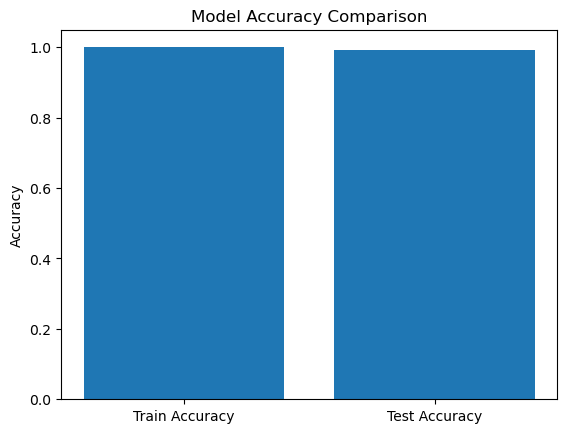

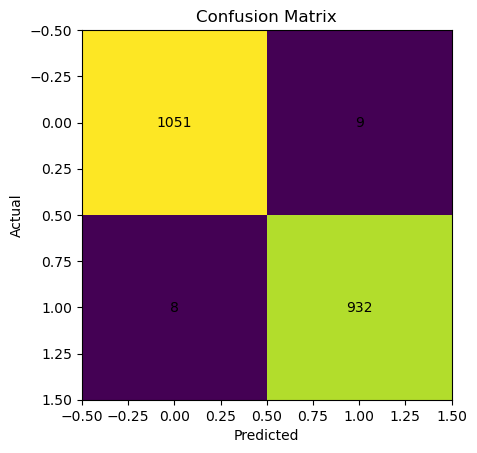

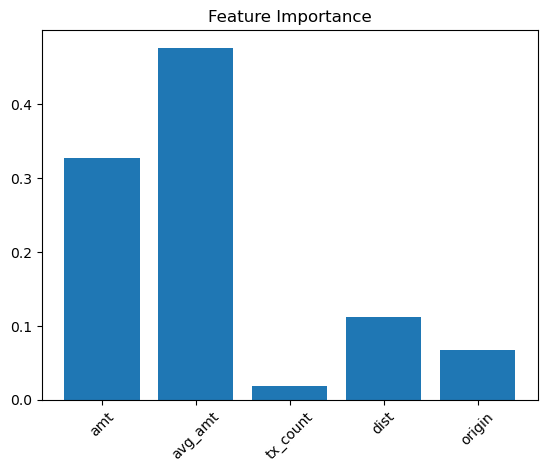


✅ Files Created Successfully:
   → sentinel_model.pkl (Model)
   → ml_proofs.json (Metrics + Proofs)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Generate Dataset
n = 10000
data = pd.DataFrame({
    'amt': np.random.uniform(100, 250000, n),
    'avg_amt': np.random.uniform(500, 100000, n),
    'tx_count': np.random.randint(1, 500, n),
    'dist': np.random.uniform(0, 1000, n),
    'origin': np.random.randint(0, 2, n)
})

# 2. Fraud Logic
condition = ((data['amt'] > (data['avg_amt'] * 3)) | ((data['origin'] == 1) & (data['dist'] > 800)))
data['label'] = condition.astype(int)

# 3. Split & Train
X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 4. Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

# =========================
# 📊 PRINT REPORT
# =========================
print("\n" + "="*60)
print("🚀 FRAUD DETECTION MODEL REPORT")
print("="*60)

print(f"\n📌 Training Accuracy     : {train_acc:.4f}")
print(f"📌 Validation Accuracy   : {test_acc:.4f}")

print("\n🔍 Classification Metrics:")
print(f"   Precision            : {precision:.4f}")
print(f"   Recall               : {recall:.4f}")
print(f"   F1 Score             : {f1:.4f}")

print("\n📊 Confusion Matrix:")
print(cm)

print("\n🔎 Sample Predictions (Actual vs Predicted):")
for a, p in zip(y_test[:5], y_test_pred[:5]):
    print(f"   Actual: {a}  ->  Predicted: {p}")

print("\n" + "="*60)

# =========================
# 📈 GRAPHS
# =========================

# 1. Accuracy Bar Graph
plt.figure()
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# 2. Confusion Matrix Heatmap (simple)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

# 3. Feature Importance
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# =========================
# 💾 SAVE FILES
# =========================
proofs = {
    "training_accuracy": float(train_acc),
    "validation_accuracy": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist(),
    "samples": [{"actual": int(a), "predicted": int(p)} for a, p in zip(y_test[:5], y_test_pred[:5])]
}

with open('ml_proofs.json', 'w') as f:
    json.dump(proofs, f)

joblib.dump(model, 'sentinel_model.pkl')

print("\n✅ Files Created Successfully:")
print("   → sentinel_model.pkl (Model)")
print("   → ml_proofs.json (Metrics + Proofs)")
print("="*60)

In [6]:
import sys
import json
import os
from datetime import datetime
from PyQt6.QtWidgets import (
    QApplication, QWidget, QVBoxLayout, QHBoxLayout, QListWidget,
    QListWidgetItem, QLineEdit, QPushButton, QLabel, QComboBox,
    QDateEdit, QMessageBox, QCheckBox, QMenu, QFrame, QGraphicsDropShadowEffect
)
from PyQt6.QtCore import Qt, QDate, QSize
from PyQt6.QtGui import QIcon, QColor, QFont, QAction

# --- STYLESHEET (The "Better UI" Secret Sauce) ---
STYLESHEET = """
QWidget {
    background-color: #121212;
    color: #E0E0E0;
    font-family: 'Segoe UI', sans-serif;
    font-size: 14px;
}

QLabel#TitleLabel {
    font-size: 28px;
    font-weight: bold;
    color: #BB86FC;
    margin: 10px;
}

QLineEdit, QComboBox, QDateEdit {
    background-color: #1E1E1E;
    border: 1px solid #333333;
    border-radius: 6px;
    padding: 8px;
    selection-background-color: #BB86FC;
}

QLineEdit:focus {
    border: 1px solid #BB86FC;
}

QPushButton {
    background-color: #BB86FC;
    color: #000000;
    border-radius: 6px;
    padding: 8px 16px;
    font-weight: bold;
}

QPushButton:hover {
    background-color: #D7B7FD;
}

QPushButton#SecondaryBtn {
    background-color: #333333;
    color: #E0E0E0;
}

QListWidget {
    border: none;
    background-color: transparent;
    outline: none;
}

QFrame#TaskCard {
    background-color: #1E1E1E;
    border-radius: 10px;
    border: 1px solid #2C2C2C;
}

QCheckBox::indicator {
    width: 20px;
    height: 20px;
    border-radius: 10px;
    border: 2px solid #BB86FC;
}

QCheckBox::indicator:checked {
    background-color: #BB86FC;
    image: url(check_icon.png); /* You can add an icon here */
}
"""

DATA_FILE = "todo_data_v2.json"

class TodoItem:
    def __init__(self, text, completed=False, deadline=None, priority="Medium"):
        self.text = text
        self.completed = completed
        self.deadline = deadline
        self.priority = priority

    def to_dict(self):
        return self.__dict__

    @staticmethod
    def from_dict(data):
        return TodoItem(**data)

class TaskWidget(QFrame):
    """Custom widget for task cards"""
    def __init__(self, task, toggle_callback, parent=None):
        super().__init__(parent)
        self.setObjectName("TaskCard")
        self.task = task
        
        layout = QHBoxLayout(self)
        layout.setContentsMargins(15, 10, 15, 10)

        # Completion Checkbox
        self.checkbox = QCheckBox()
        self.checkbox.setChecked(task.completed)
        self.checkbox.stateChanged.connect(lambda s: toggle_callback(task, s))
        layout.addWidget(self.checkbox)

        # Task Text and Deadline
        text_container = QVBoxLayout()
        self.text_label = QLabel(task.text)
        self.text_label.setWordWrap(True)
        if task.completed:
            self.text_label.setStyleSheet("text-decoration: line-through; color: #757575;")
        
        self.deadline_label = QLabel(f"📅 {task.deadline}")
        self.deadline_label.setStyleSheet("font-size: 11px; color: #03DAC6;")
        
        text_container.addWidget(self.text_label)
        text_container.addWidget(self.deadline_label)
        layout.addLayout(text_container, stretch=1)

        # Priority Badge
        priority_colors = {"High": "#CF6679", "Medium": "#F2994A", "Low": "#03DAC6"}
        self.p_label = QLabel(task.priority.upper())
        self.p_label.setFixedWidth(70)
        self.p_label.setAlignment(Qt.AlignmentFlag.AlignCenter)
        self.p_label.setStyleSheet(f"""
            background-color: {priority_colors.get(task.priority)};
            color: black;
            font-size: 10px;
            font-weight: bold;
            border-radius: 4px;
            padding: 2px;
        """)
        layout.addWidget(self.p_label)

class TodoApp(QWidget):
    def __init__(self):
        super().__init__()
        self.tasks = []
        self.init_ui()
        self.load_tasks()

    def init_ui(self):
        self.setWindowTitle("TaskFlow Pro")
        self.resize(500, 700)
        self.setStyleSheet(STYLESHEET)

        main_layout = QVBoxLayout(self)
        main_layout.setSpacing(20)
        main_layout.setContentsMargins(30, 30, 30, 30)

        # --- Header ---
        header_layout = QVBoxLayout()
        title = QLabel("My Tasks")
        title.setObjectName("TitleLabel")
        self.stats_label = QLabel("0 tasks remaining")
        self.stats_label.setStyleSheet("color: #757575; margin-left: 12px;")
        header_layout.addWidget(title)
        header_layout.addWidget(self.stats_label)
        main_layout.addLayout(header_layout)

        # --- Input Section ---
        input_card = QFrame()
        input_card.setObjectName("TaskCard")
        input_layout = QVBoxLayout(input_card)

        self.task_input = QLineEdit()
        self.task_input.setPlaceholderText("What needs to be done?")
        input_layout.addWidget(self.task_input)

        settings_row = QHBoxLayout()
        self.deadline_edit = QDateEdit(calendarPopup=True)
        self.deadline_edit.setDate(QDate.currentDate())
        
        self.priority_combo = QComboBox()
        self.priority_combo.addItems(["Low", "Medium", "High"])
        self.priority_combo.setCurrentIndex(1)

        settings_row.addWidget(QLabel("Due:"))
        settings_row.addWidget(self.deadline_edit)
        settings_row.addWidget(QLabel("Priority:"))
        settings_row.addWidget(self.priority_combo)
        input_layout.addLayout(settings_row)

        add_btn = QPushButton("Add Task")
        add_btn.clicked.connect(self.add_task)
        input_layout.addWidget(add_btn)
        
        main_layout.addWidget(input_card)

        # --- List ---
        self.task_list = QListWidget()
        self.task_list.setSpacing(8) # Space between cards
        self.task_list.setContextMenuPolicy(Qt.ContextMenuPolicy.CustomContextMenu)
        self.task_list.customContextMenuRequested.connect(self.show_context_menu)
        main_layout.addWidget(self.task_list)

        # --- Footer Controls ---
        footer = QHBoxLayout()
        for text, func in [("Sort Date", self.sort_by_deadline), 
                           ("Sort Priority", self.sort_by_priority), 
                           ("Clear Done", self.clear_completed)]:
            btn = QPushButton(text)
            btn.setObjectName("SecondaryBtn")
            btn.clicked.connect(func)
            footer.addWidget(btn)
        
        main_layout.addLayout(footer)

    def add_task(self):
        text = self.task_input.text().strip()
        if not text: return

        task = TodoItem(
            text=text,
            deadline=self.deadline_edit.date().toString("yyyy-MM-dd"),
            priority=self.priority_combo.currentText()
        )
        self.tasks.append(task)
        self.refresh_task_list()
        self.task_input.clear()
        self.save_tasks()

    def refresh_task_list(self):
        self.task_list.clear()
        incomplete_count = 0
        
        for task in self.tasks:
            if not task.completed: incomplete_count += 1
            
            item_widget = TaskWidget(task, self.toggle_complete)
            list_item = QListWidgetItem(self.task_list)
            list_item.setSizeHint(item_widget.sizeHint())
            self.task_list.setItemWidget(list_item, item_widget)
        
        self.stats_label.setText(f"{incomplete_count} tasks remaining today")

    def toggle_complete(self, task, state):
        task.completed = (state == 2) # 2 is Checked
        self.refresh_task_list()
        self.save_tasks()

    def show_context_menu(self, pos):
        item = self.task_list.itemAt(pos)
        if not item: return
        
        menu = QMenu()
        menu.setStyleSheet("background-color: #2C2C2C; color: white; border: 1px solid #444;")
        
        del_action = QAction("🗑 Delete Task", self)
        del_action.triggered.connect(lambda: self.delete_task(item))
        menu.addAction(del_action)
        menu.exec(self.task_list.mapToGlobal(pos))

    def delete_task(self, item):
        idx = self.task_list.row(item)
        self.tasks.pop(idx)
        self.refresh_task_list()
        self.save_tasks()

    def sort_by_deadline(self):
        self.tasks.sort(key=lambda t: t.deadline)
        self.refresh_task_list()

    def sort_by_priority(self):
        p_map = {"High": 0, "Medium": 1, "Low": 2}
        self.tasks.sort(key=lambda t: p_map[t.priority])
        self.refresh_task_list()

    def clear_completed(self):
        self.tasks = [t for t in self.tasks if not t.completed]
        self.refresh_task_list()
        self.save_tasks()

    def save_tasks(self):
        with open(DATA_FILE, "w") as f:
            json.dump([t.to_dict() for t in self.tasks], f)

    def load_tasks(self):
        if os.path.exists(DATA_FILE):
            try:
                with open(DATA_FILE, "r") as f:
                    self.tasks = [TodoItem.from_dict(d) for d in json.load(f)]
                self.refresh_task_list()
            except: pass

if __name__ == "__main__":
    app = QApplication(sys.argv)
    app.setStyle("Fusion") # Base style for consistency
    win = TodoApp()
    win.show()
    sys.exit(app.exec())

ModuleNotFoundError: No module named 'PyQt6'